# Generating a Basic Tone:

The carrier wave, $c(t)$ can be modeled by the equation:
$c(t) = A*sin(2\pi*f + \phi) + O$, where $A$ is the amplitude of the sine wave and $O$ is the offset.

In [325]:
import numpy as np

def carrier_wave(x, frequency = 700, amplitude = 1, phase = 0, offset = 0):
    return (amplitude * np.sin(2 * np.pi * frequency * x + phase) + offset)

duration = 5
sample_rate = 8000

total_samples = 5*8000

x_values = np.linspace(start = 0, stop = 5, num = total_samples)
c_t = carrier_wave(x_values)

An $8 \text{ kHz}$ sample rate seems like enough for generating synthetic data.

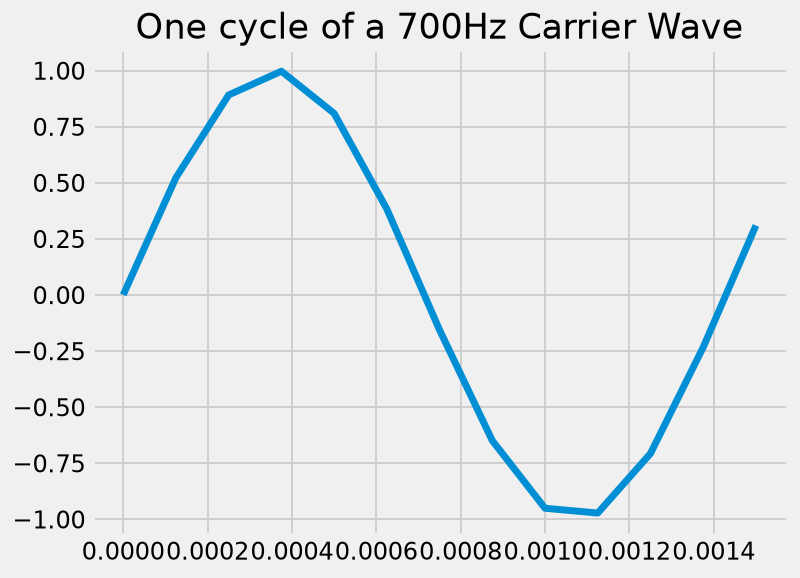

In [326]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.plot(x_values[0:13], c_t[0:13])
plt.title("One cycle of a 700Hz Carrier Wave")
plt.style.use("fivethirtyeight")
plt.show()

Basic math here, but it's nice to realize why this models a full cycle:

$700 \text{ Hz} = 700 \frac{\text{cycles}}{ second} = \frac{1 \text{second}}{700 \text{ cycles}}$

The inverse gives $\frac{\text{seconds}}{\text{cycles}}$:

$\frac{1 \text{ seconds}}{700 \text{ cycles}} * \text {sample rate} = \text{target}$

Now, there's enough to try saving this to a .wav so it's playable:

In [327]:
from scipy.io import wavfile

# Convert the data to PCM & int16 for the computer's sound card:
audio_int16 = (c_t * 32767).astype(np.int16)
audio_file = wavfile.write("700hz-5sec.wav", sample_rate, audio_int16)

In [328]:
from IPython.display import Audio, display
display(Audio("700hz-5sec.wav"))

# Generating the Modulation for OOK:

Essentially, we're modeling a CW key here:

## Side-trip: Understanding dit length and PARIS standard

Words per minute (WPM) is the usual way to represent speed of typing or writing, etc. The same's true for CW. However, we need to know the speed at which we tap the key. But, some words are longer than others, so some sort of average had to be established as a baseline.

For reasons that are unclear, the word "PARIS" was chosen.
PARIS in CW Code is represented as:

P: dit-dah-dah-dit

A: dit-dah

R: dit-dah-dit

I: dit-dit

S: dit-dit-dit

Number of dits: 10

number of dah: 4

a dit represents 1 unit, a dah 3 units. Intra-character gaps have 1 silent unit, inter-character gaps have 3 units, word gaps have 7 units.
10 + 4*3 + 4*3 + 9 + 7 = 50

So, the agreed average is then $\frac{50 \text{ units}}{word}$

This gives a formula for dit duration for any given WPM as: $t_d = \frac{60}{50* \text{WPM}} = \frac{1.2}{\text{WPM}}$



# Representing a key-down event as a binary function

In [329]:
cw_alphabet = {
    "a": "10111",
    "b": "111010101",
    "c": "11101011101",
    "d": "1110101",
    "e": "1",
    "f": "101011101",
    "g": "111011101",
    "h": "1010101",
    "i": "101",
    "j": "1011101110111",
    "k": "111010111",
    "l": "101110101",
    "m": "1110111",
    "n": "11101",
    "o": "11101110111",
    "p": "10111011101",
    "q": "1110111010111",
    "r": "1011101",
    "s": "10101",
    "t": "111",
    "u": "1010111",
    "v": "101010111",
    "w": "101110111",
    "x": "11101010111",
    "y": "1110101110111",
    "z": "11101110101"
}


cw_alphabet.get("pi")

In [330]:
def word_to_ook_tau(word):
    cw_code = [0]
    for letter in word.lower():
        mapping = cw_alphabet.get(letter)
        cw_code += list(mapping)
        cw_code += list("000")       # Don't forget the intra-word spacing!
        
    cw_code += list("000")    # nor the inter-word spacing (3 from last letter)!

    return [int(x) for x in cw_code]

In [331]:
key_interval = word_to_ook_tau("PARIS")
print(key_interval)

[0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0]


So now `key_interval` is all the intervals we care about, in terms of raw timing units, or "beats" to borrow a music term. But, we ultimately need this sequence in terms of samples.

In [332]:
# def ook_sr_convert(key_interval, wpm=13, sample_rate=8000):
#     tau = 1.2/wpm
#     samples_per_tau = int(tau * sample_rate)

#     converted_interval = []
#     for x in key_interval:
#         converted_interval += [x for n in range(samples_per_tau)]
    
#     return converted_interval

In [333]:
def ook_sr_convert(key_interval, wpm=10, sample_rate=8000):
    tau = 1.2 / wpm
    samples_per_tau = tau * sample_rate          # keep as float, don't round yet

    # boundary[i] = sample index where unit i begins, computed from absolute
    # elapsed time (i * samples_per_tau), not by repeatedly stepping by a
    # truncated per-unit count
    boundaries = np.round(np.arange(len(key_interval) + 1) * samples_per_tau).astype(int)

    converted = np.zeros(boundaries[-1], dtype=int)
    for i, level in enumerate(key_interval):
        converted[boundaries[i]:boundaries[i + 1]] = level

    return converted.tolist()


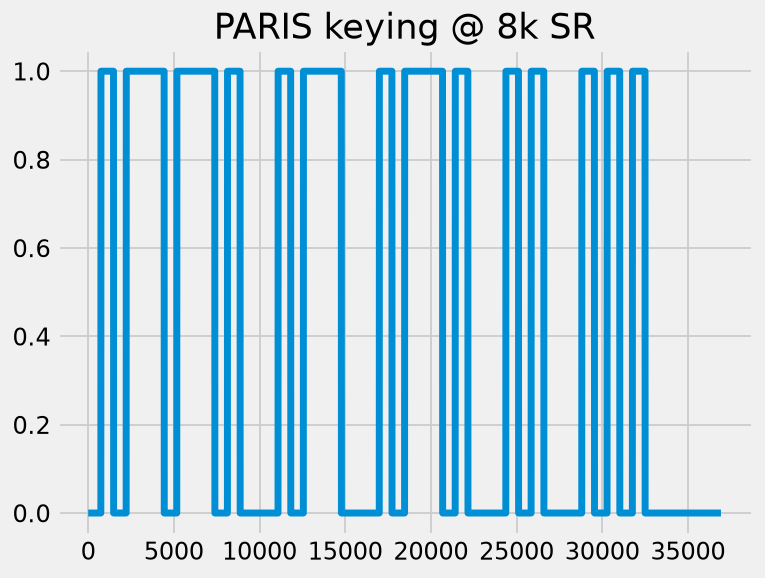

In [334]:
paris_8k = ook_sr_convert(key_interval, wpm=13)
x_values = np.linspace(0, len(paris_8k), len(paris_8k))
m_t = paris_8k


import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.plot(x_values, paris_8k)
plt.title("PARIS keying @ 8k SR")
plt.style.use("fivethirtyeight")
plt.show()

# Mixing with the carrier wave

Now, the signal gets mixed. Mixing two sinusoids can be represented as the product of the two frequencies. On-off-keying makes this very intuitive to understand: 

When the key is depressed, $1 * c(t) = c(t)$, else $0$ (silence).

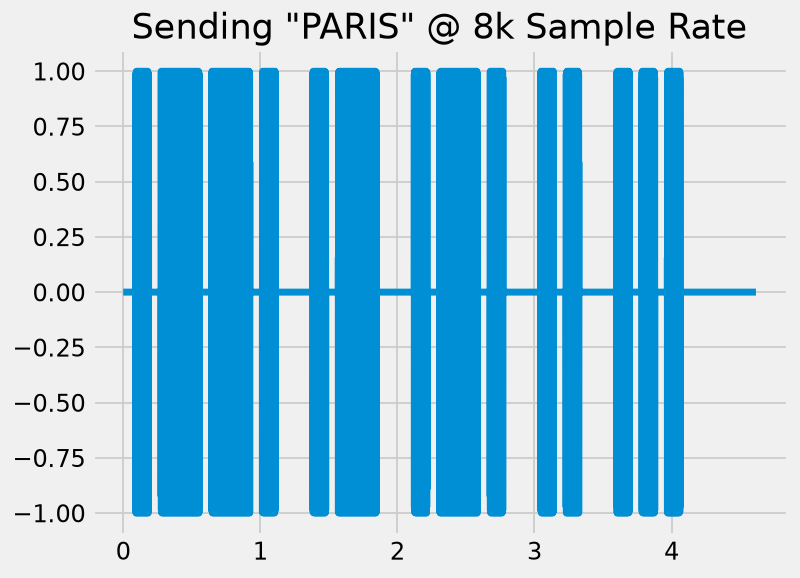

In [335]:
import matplotlib.pyplot as plt

t_values = np.arange(len(paris_8k)) / sample_rate
c_t = carrier_wave(t_values)
mixed_signal = paris_8k * c_t

fig, ax = plt.subplots()

ax.plot(t_values, mixed_signal)
plt.title("Sending \"PARIS\" @ 8k Sample Rate")
plt.style.use("fivethirtyeight")
plt.show()

In [336]:
audio_int16 = (mixed_signal * 32767).astype(np.int16)
audio_file = wavfile.write("PARIS-700hz-mixed.wav", sample_rate, audio_int16)